# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# In Colab, upload FlashEats_Classroom_Pack.zip when prompted.

BASE = Path("C:/Users/harsh/Documents/SST/Forward Deployed Engineer/flasheats-classroom-pack")

if not BASE.exists():
    try:
        from google.colab import files
        print("Upload FlashEats_Classroom_Pack.zip")
        uploaded = files.upload()
        zip_name = next(name for name in uploaded if name.endswith(".zip"))
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall("/content")
    except Exception as e:
        print("If running locally, set BASE manually to the extracted pack.")
        print(e)

print("BASE:", BASE)
print("Exists:", BASE.exists())

BASE: C:\Users\harsh\Documents\SST\Forward Deployed Engineer\flasheats-classroom-pack
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | SQLite `orders.promised_eta` (**authoritative**). Dispatch API `current_delivery_eta` is only contextual. | `promised_eta` is what the customer was promised at checkout, so "late" is measured against it. The API ETA is a later, revised estimate. |
| Actual delivery time | SQLite `orders.actual_delivery_at` (**authoritative**). `driver_events.json` → `delivered` is the cross-check / backfill. | This is the system of record for order completion. Driver events are a second copy captured from the driver app. |
| Driver assignment | Dispatch API (`driver_id`, `original_driver_id`, `assigned_at`, `reassigned_at`) (**authoritative**). `driver_events.json` → `assigned` is a cross-check. | Dispatch owns the assignment decision and is the only source that records reassignment. `orders.driver_id` stores only the original driver. |
| Customer complaint | `support_tickets.csv` (**authoritative for what the customer said**, not for what happened) | Tickets show how the customer experienced the order. They are self-reported and incomplete, since most late orders never raise a ticket. |
| Restaurant status | `restaurant_status.csv` (**contextual only**) | It is one manual "last update" snapshot per order, covers only part of the orders and has no history. |
| Driver movement/events | `driver_events.json` (**contextual**) | GPS pings plus pickup and delivery events are good for corroborating and inferring. Pings are sparse, so they cannot give exact arrival times. |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

**Answer:**
- **Authoritative:** a fact is authoritative in the system that *creates* it.
  - Orders (SQLite) is authoritative for the promise and the order lifecycle.
  - Dispatch is authoritative for driver assignment.
  - Tickets are authoritative for what the customer said.
- **Contextual:** restaurant status (manual, one snapshot per order) and GPS pings (sparse) are only contextual. We use them to form hypotheses, not to set the KPI.

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** `actual_delivery_at > promised_eta`, i.e. any positive delay. A second view with a >10 min threshold is reported for severity.
- **Denominator:** unique orders with status `delivered` (case-normalised, so `Delivered` counts) **and** a recorded `actual_delivery_at`.
- **Cancelled orders:** excluded from the late rate because they have no delivery time. They are reported separately as failed promises.
- **Missing actual delivery timestamp:** excluded from the rate and the count is reported. The driver-app `delivered` event is used only as a sensitivity check, not silently merged in.
- **Row grain:** one row should be one order. The raw table has 1,603 rows for 1,600 order IDs, so we deduplicate on `order_id` first.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
# Starter syntax only — complete the analysis yourself.

# SQL examples:
# SELECT order_id, promised_eta, actual_delivery_at, final_status
# FROM orders
# WHERE ...

query = """
SELECT *
FROM orders
LIMIT 20;
"""

orders_preview = pd.read_sql(query, con)
display(orders_preview)

# Useful pandas syntax:
# df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")
# df["delay_min"] = (df["actual"] - df["promised"]).dt.total_seconds() / 60
# df["order_id"].duplicated().sum()
# df.isna().sum()

# Solution: see the cells below

,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear
5,O00006,C0152,R052,D120,Bengaluru,2026-08-26T23:02:00,2026-08-26T23:58:18.214888,2026-08-26T23:31:33.631520,2026-08-27T00:05:36.182189,delivered,6.81,high,clear
6,O00007,C0875,R021,D094,Bengaluru,2026-08-14T11:47:00,2026-08-14T13:14:54,2026-08-14T12:06:06.040105,2026-08-14T13:19:10.066680,delivered,18.00,severe,rain
7,O00008,C0223,R010,D031,Bengaluru,2026-08-27T22:22:00,2026-08-27T23:40:06,2026-08-27T23:11:00.536098,2026-08-28T00:06:57.494136,delivered,18.00,medium,rain
8,O00009,C0685,R053,D078,Bengaluru,2026-08-09T13:16:00,2026-08-09T14:21:32.383307,2026-08-09T13:48:11.662156,2026-08-09T14:22:13.491008,delivered,14.54,low,clear
9,O00010,C0530,R006,D082,Bengaluru,2026-08-22T13:27:00,2026-08-22T14:28:13.625987,2026-08-22T13:51:04.636196,2026-08-22T14:22:26.150344,delivered,12.49,low,clear


In [5]:
# Challenge 1 - size the late-delivery problem

orders_raw = pd.read_sql("SELECT * FROM orders", con)
print("Raw rows:", len(orders_raw), "| Unique order_ids:", orders_raw["order_id"].nunique())

# Duplicate order_ids - which fields disagree between the copies?
dups = orders_raw[orders_raw["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dups[["order_id", "promised_eta", "actual_delivery_at", "final_status", "traffic_bucket"]])

# Fix the grain: one row per order
orders_df = orders_raw.drop_duplicates("order_id", keep="first").copy()

# Parse timestamps and normalise status text ("Delivered" -> "delivered")
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    orders_df[c] = pd.to_datetime(orders_df[c], format="mixed", errors="coerce")
orders_df["status"] = orders_df["final_status"].str.strip().str.lower()
orders_df["delay_min"] = (orders_df["actual_delivery_at"] - orders_df["promised_eta"]).dt.total_seconds() / 60

print("Raw status values:", orders_raw["final_status"].value_counts().to_dict())

cancelled = orders_df[orders_df["status"] == "cancelled"]
missing_ts = orders_df[(orders_df["status"] == "delivered") & orders_df["actual_delivery_at"].isna()]
valid = orders_df[(orders_df["status"] == "delivered") & orders_df["actual_delivery_at"].notna()].copy()
valid["is_late"] = valid["delay_min"] > 0

print("\nCancelled orders:", len(cancelled))
print("Delivered but no delivery timestamp:", len(missing_ts))
print("Valid delivered orders (denominator):", len(valid))

late = valid[valid["is_late"]]
print(f"\nLate (> 0 min):  {len(late)} / {len(valid)} = {len(late) / len(valid):.1%}")
print(f"Late (> 10 min): {(valid['delay_min'] > 10).sum()} / {len(valid)} = {(valid['delay_min'] > 10).mean():.1%}")
print(f"Median lateness among late orders: {late['delay_min'].median():.1f} min")

Raw rows: 1603 | Unique order_ids: 1600


,order_id,promised_eta,actual_delivery_at,final_status,traffic_bucket
119,O00120,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,delivered,severe
1600,O00120,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,delivered,medium
722,O00723,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,delivered,medium
1601,O00723,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,delivered,high
1301,O01302,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,delivered,medium
1602,O01302,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,delivered,high


Raw status values: {'delivered': 1530, 'cancelled': 68, 'Delivered': 5}

Cancelled orders: 68
Delivered but no delivery timestamp: 37
Valid delivered orders (denominator): 1495



Late (> 0 min):  843 / 1495 = 56.4%
Late (> 10 min): 349 / 1495 = 23.3%
Median lateness among late orders: 8.0 min


In [6]:
# Worst delayed orders - are they real delays or bad data?
valid["promise_window_min"] = (valid["promised_eta"] - valid["created_at"]).dt.total_seconds() / 60
worst = valid.sort_values("delay_min", ascending=False).head(10)
display(worst[["order_id", "created_at", "promised_eta", "actual_delivery_at", "delay_min", "promise_window_min"]].round({"delay_min": 1, "promise_window_min": 1}))

# Data-quality checks that can move the metric
dq = {
    "duplicate order rows": len(orders_raw) - orders_raw["order_id"].nunique(),
    "status 'Delivered' (capitalised)": (orders_raw["final_status"] == "Delivered").sum(),
    "delivered but missing actual_delivery_at": len(missing_ts),
    "promised_eta before created_at": (orders_df["promised_eta"] < orders_df["created_at"]).sum(),
    "delivered before pickup": (orders_df["actual_delivery_at"] < orders_df["pickup_at"]).sum(),
    "traffic_bucket 'HIGH' (casing)": (orders_raw["traffic_bucket"] == "HIGH").sum(),
    "distance exactly 18.0 km (likely default)": (orders_df["distance_km_estimate"] == 18.0).sum(),
}
display(pd.Series(dq, name="rows").to_frame())

# Sensitivity: remove the impossible ETAs
clean = valid[valid["promise_window_min"] > 0]
print(f"Late rate without impossible ETAs: {clean['is_late'].mean():.1%} (n={len(clean)})")

,order_id,created_at,promised_eta,actual_delivery_at,delay_min,promise_window_min
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,-10.0
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,-10.0
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,-10.0
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,-10.0
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,61.8
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,79.8
1101,O01102,2026-08-12 18:25:00,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,45.0,66.2
193,O00194,2026-08-11 17:36:00,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.3,85.8
1311,O01312,2026-08-14 19:02:00,2026-08-14 20:17:36.000000,2026-08-14 20:54:36.321890,37.0,75.6
1402,O01403,2026-08-24 17:26:00,2026-08-24 18:47:36.000000,2026-08-24 19:24:32.047659,36.9,81.6


,rows
duplicate order rows,3
status 'Delivered' (capitalised),5
delivered but missing actual_delivery_at,37
promised_eta before created_at,4
delivered before pickup,5
traffic_bucket 'HIGH' (casing),3
distance exactly 18.0 km (likely default),806


Late rate without impossible ETAs: 56.3% (n=1491)


### Challenge 1 — Answer

| Item | Result |
|---|---|
| Raw rows → unique orders | 1,603 → **1,600**. There are 3 duplicate IDs (O00120, O00723, O01302). The copies are identical except for `traffic_bucket`. |
| Cancelled | **68** (4.3% of orders), reported separately |
| Delivered but no delivery timestamp | **37**, excluded and reported |
| **Valid delivered orders** | **1,495** |
| **Late (> 0 min)** | **843 / 1,495 = 56.4%** |
| Late (> 10 min) | 349 / 1,495 = **23.3%** |
| Median lateness of late orders | **≈ 8.0 min** |

**Worst delayed orders:**
- The top 4 (O00104, O00102, O00101, O00103, all 69–87 min late) have a `promised_eta` **10 minutes before the order was created**. That is impossible. Their "delay" is an ETA-generation error, not a real delay.
- The first genuinely worst order is O01081, at about 50 min late.

**Data-quality issues that change the metric:**
1. **Grain:** 3 duplicated orders. Without deduping they are counted twice, and their copies disagree on traffic.
2. **Status casing:** 5 rows say `Delivered`. An exact `= 'delivered'` filter silently drops them.
3. **Missing delivery timestamps (37):** the rate is computed on 1,495 orders, not 1,532. The driver app has a `delivered` event for all 37 (see Challenge 5). Adding them would give ~56.6%.
4. **Impossible ETAs (4):** these inflate the worst-delay list and mean lateness. Removing them gives 56.3%.
5. **Delivered before pickup (5):** O00051–O00055 have a broken chronology.
6. **Distance = 18.0 km for ~50% of orders:** this looks like a default or placeholder. It does not change the late rate, but it makes distance unusable as an explanatory variable.

**Bottom line:**
- About **56%** of delivered orders arrived after the promised ETA. The typical miss is small (median ~8 min).
- Only **~23%** are more than 10 minutes late. How big "the problem" looks depends on the definition.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

In [7]:
# Checkpoint - same data, different choices -> different answers
raw = orders_raw.copy()
raw["delay_min"] = (pd.to_datetime(raw["actual_delivery_at"], format="mixed")
                    - pd.to_datetime(raw["promised_eta"], format="mixed")).dt.total_seconds() / 60
exact = orders_df[(orders_df["final_status"] == "delivered") & orders_df["actual_delivery_at"].notna()]

variants = [
    ("Raw rows, exact 'delivered', no dedupe", raw[(raw["final_status"] == "delivered") & raw["delay_min"].notna()]["delay_min"]),
    ("Deduped, exact 'delivered' only", exact["delay_min"]),
    ("Deduped, normalised status (our answer)", valid["delay_min"]),
]
rows = [(name, len(s), round(100 * (s > 0).mean(), 1)) for name, s in variants]
rows.append(("Late > 10 min instead of > 0", len(valid), round(100 * (valid["delay_min"] > 10).mean(), 1)))
rows.append(("Denominator = all 1,600 orders", len(orders_df), round(100 * valid["is_late"].sum() / len(orders_df), 1)))
rows.append(("Cancelled counted as failed/late", len(valid) + len(cancelled),
             round(100 * (valid["is_late"].sum() + len(cancelled)) / (len(valid) + len(cancelled)), 1)))

display(pd.DataFrame(rows, columns=["choice", "denominator", "late_%"]))

,choice,denominator,late_%
0,"Raw rows, exact 'delivered', no dedupe",1493,56.3
1,"Deduped, exact 'delivered' only",1490,56.4
2,"Deduped, normalised status (our answer)",1495,56.4
3,Late > 10 min instead of > 0,1495,23.3
4,"Denominator = all 1,600 orders",1600,52.7
5,Cancelled counted as failed/late,1563,58.3


**Checkpoint — why teams disagree:**
- The data grain (dedupe vs not) and the status casing change the answer by only a few orders. The rate stays at ~56.4%.
- The **definition** and the **denominator** move it a lot:
  - **23.3%** with a >10 min threshold.
  - **52.7%** if cancelled orders stay in the denominator.
  - **58.3%** if cancelled orders are counted as failed promises.
- So when two teams get different numbers, compare the definition and the denominator first, then the row cleaning.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [8]:
# Starter ideas:
# df.groupby("traffic_bucket")["delay_min"].agg(["count","median","mean"])
# df.groupby("weather_bucket")["delay_min"].agg(["count","median","mean"])

# Example plotting syntax:
# summary.plot(kind="bar")
# plt.title("...")
# plt.show()

# Solution: see the cells below

In [9]:
# Challenge 2 - is traffic the problem? Compare several dimensions
df = valid.copy()
df["traffic"] = df["traffic_bucket"].str.lower()                                        # 'HIGH' -> 'high'
df["pickup_wait_min"] = (df["pickup_at"] - df["created_at"]).dt.total_seconds() / 60     # order placed -> picked up
df["ride_min"] = (df["actual_delivery_at"] - df["pickup_at"]).dt.total_seconds() / 60    # picked up -> delivered

def summarise(col):
    # late rate plus where the time goes, for each group
    return (df.groupby(col, observed=True)
              .agg(orders=("order_id", "count"),
                   late_rate=("is_late", "mean"),
                   median_delay=("delay_min", "median"),
                   median_promise=("promise_window_min", "median"),
                   median_pickup_wait=("pickup_wait_min", "median"),
                   median_ride=("ride_min", "median"))
              .round(2))

print("1) Traffic")
display(summarise("traffic").loc[["low", "medium", "high", "severe"]])

print("2) Weather")
display(summarise("weather_bucket").loc[["clear", "rain", "heavy_rain"]])

# 18.0 km looks like a default value, so keep it as its own group
df["distance_band"] = pd.cut(df["distance_km_estimate"], [0, 5, 10, 15, 17.99, 18.0, 100],
                             labels=["0-5", "5-10", "10-15", "15-18", "18.0 (default?)", ">18"])
print("3) Distance")
display(summarise("distance_band"))

1) Traffic


,orders,late_rate,median_delay,median_promise,median_pickup_wait,median_ride
traffic,,,,,,
low,360,0.49,-0.09,72.80,25.82,43.48
medium,588,0.51,0.26,75.45,25.88,46.74
high,424,0.67,3.99,79.80,26.98,53.02
severe,123,0.66,4.26,85.40,25.53,61.79


2) Weather


,orders,late_rate,median_delay,median_promise,median_pickup_wait,median_ride
weather_bucket,,,,,,
clear,1192,0.53,0.78,72.80,26.15,45.99
rain,231,0.67,4.27,75.30,26.53,51.87
heavy_rain,72,0.74,6.63,81.45,24.78,60.02


3) Distance


,orders,late_rate,median_delay,median_promise,median_pickup_wait,median_ride
distance_band,,,,,,
0-5,69,0.54,0.59,45.72,25.05,20.05
5-10,222,0.56,1.02,56.39,25.66,30.78
10-15,300,0.53,0.64,65.85,26.60,40.49
15-18,152,0.63,2.69,74.44,26.80,49.30
18.0 (default?),749,0.57,1.44,75.60,25.95,52.18
>18,3,1.00,26.32,79.80,49.65,55.87


In [10]:
# 4) Where does the delay build up - before pickup or on the road?
print("Correlation with delay_min:")
print(df[["pickup_wait_min", "ride_min", "promise_window_min"]].corrwith(df["delay_min"]).round(2))

df["pickup_wait_quartile"] = pd.qcut(df["pickup_wait_min"], 4, labels=["Q1 fastest", "Q2", "Q3", "Q4 slowest"])
df["ride_quartile"] = pd.qcut(df["ride_min"], 4, labels=["Q1 shortest", "Q2", "Q3", "Q4 longest"])

print("\nBy time from order to pickup")
display(summarise("pickup_wait_quartile"))
print("By time on the road")
display(summarise("ride_quartile"))

Correlation with delay_min:
pickup_wait_min       0.83
ride_min              0.21
promise_window_min   -0.02
dtype: float64

By time from order to pickup


,orders,late_rate,median_delay,median_promise,median_pickup_wait,median_ride
pickup_wait_quartile,,,,,,
Q1 fastest,374,0.03,-8.38,72.80,16.73,47.25
Q2,374,0.37,-1.55,72.80,23.48,46.85
Q3,373,0.86,4.43,72.80,29.35,47.06
Q4 slowest,374,0.99,15.49,74.34,40.03,48.09


By time on the road


,orders,late_rate,median_delay,median_promise,median_pickup_wait,median_ride
ride_quartile,,,,,,
Q1 shortest,374,0.49,-0.27,56.60,25.98,30.41
Q2,374,0.48,-0.41,71.18,25.86,44.02
Q3,373,0.57,1.52,75.60,26.52,50.41
Q4 longest,374,0.72,4.52,79.80,25.73,58.47


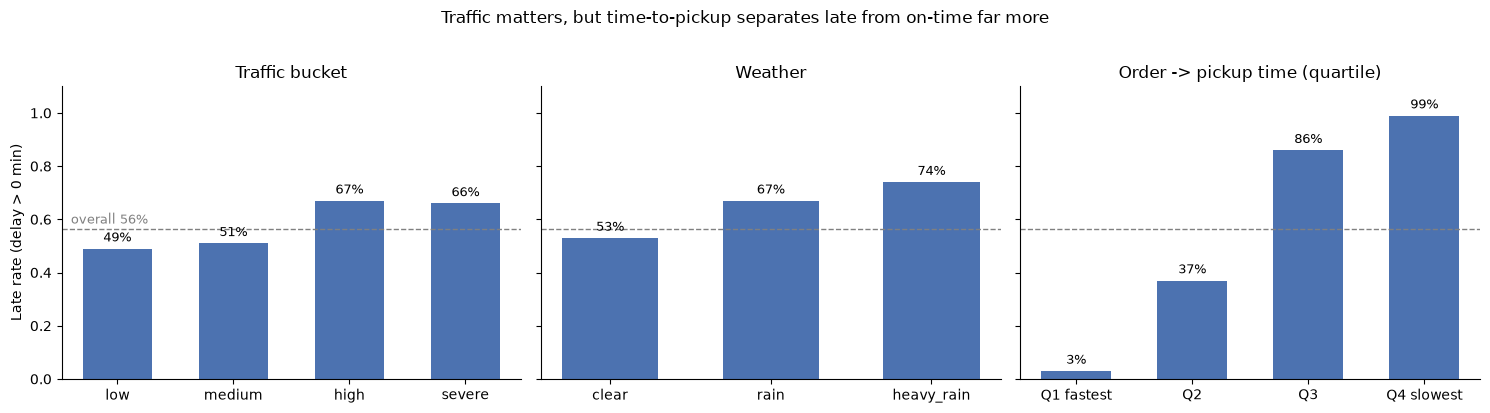

In [11]:
# One chart: late rate by traffic, weather and order->pickup time
panels = [
    ("Traffic bucket", summarise("traffic").loc[["low", "medium", "high", "severe"], "late_rate"]),
    ("Weather", summarise("weather_bucket").loc[["clear", "rain", "heavy_rain"], "late_rate"]),
    ("Order -> pickup time (quartile)", summarise("pickup_wait_quartile")["late_rate"]),
]
overall = df["is_late"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (title, s) in zip(axes, panels):
    bars = ax.bar(s.index.astype(str), s.values, color="#4C72B0", width=0.6)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in s.values], padding=3, fontsize=9)
    ax.axhline(overall, ls="--", lw=1, color="grey")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Late rate (delay > 0 min)")
axes[0].text(-0.4, overall + 0.02, f"overall {overall:.0%}", color="grey", fontsize=9)
axes[0].set_ylim(0, 1.1)
plt.suptitle("Traffic matters, but time-to-pickup separates late from on-time far more", y=1.02)
plt.tight_layout()
plt.show()

### Challenge 2 — Answer

**Comparisons (delivered orders, n = 1,495):**

| Dimension | Late rate | What else changes |
|---|---|---|
| Traffic: low / medium vs high / severe | 49% / 51% vs **67% / 66%** | The ride leg is longer (median 43–47 → 53–62 min). The promise is also longer (73 → 80–85 min), so the ETA already partly adjusts for traffic. |
| Weather: clear vs rain / heavy rain | 53% vs **67% / 74%** | Ride time is longer. Heavy rain is only 72 orders. |
| Distance | 53–63%, no clear trend | 50% of rows are exactly 18.0 km, so this field cannot be trusted for analysis. |
| **Order → pickup time, fastest → slowest quartile** | **3% → 37% → 86% → 99%** | Correlation with delay is **0.83** (ride time is only 0.21). Pickup wait is about the same (~26 min) in every traffic bucket. |

**Hypothesis supported by the evidence:**
- Lateness is mainly created **before pickup**, in the time from order to driver pickup.
- Traffic and rain add a smaller, second effect on the road.
- The promised ETA stretches for distance and traffic, but not for a slow first mile. When pickup runs long, the order is almost always late.

**Alternative explanation we cannot rule out:**
- "Order → pickup" mixes **restaurant prep time** and **driver arrival time**. There is no "driver arrived at restaurant" or "food ready" event, so we cannot tell whether the kitchen or the driver is the bottleneck.
- Traffic may also be a **confounder**: rain and peak traffic could raise restaurant load at the same time.

**Association vs causation:**
- The data shows that traffic and rain are **associated** with more late orders, and that long pickup waits are **strongly associated** with lateness.
- It does not prove that traffic *causes* the delay. This is observational data with no controlled comparison.
- **"Traffic is the problem" is only partly true. The bigger signal is the first mile.**

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [12]:
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())

# Join syntax if useful:
# merged = tickets.merge(order_analysis, on="order_id", how="left")

# Solution: see the cells below

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1


In [13]:
# Challenge 3 - what are customers actually telling us?
print("Rows:", len(tickets), "| Unique ticket_ids:", tickets["ticket_id"].nunique())
display(tickets[tickets["ticket_id"].duplicated(keep=False)])   # is it an exact duplicate?

tk = tickets.drop_duplicates().copy()
print("Tickets without an order_id:", tk["order_id"].isna().sum())

# repr() reveals hidden spaces and casing differences
print("\nRaw category labels:")
print(tk["category"].map(repr).value_counts())

# Safe normalisation only: trim + lowercase + spaces -> underscores
tk["category_norm"] = tk["category"].str.strip().str.lower().str.replace(" ", "_")

# Does each label always go with the same customer message?
display(tk.groupby(["category_norm", "customer_message"]).size().to_frame("tickets"))

Rows: 202 | Unique ticket_ids: 201


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


Tickets without an order_id: 3

Raw category labels:
category
'late_delivery'        37
'eta_changed'          37
'restaurant_delay'     37
'ready_but_waiting'    33
'status_mismatch'      29
'driver_not_moving'    25
'Late Delivery'         1
'late_delivery '        1
'ETA issue'             1
Name: count, dtype: int64


tickets
category_norm     customer_message                                                     
driver_not_moving The rider has not moved for 15 minutes.                            25
eta_changed       The ETA keeps changing and the food is still not here.             37
eta_issue         The rider has not moved for 15 minutes.                             1
late_delivery     My order is already past the promised time.                        38
                  The rider has not moved for 15 minutes.                             1
ready_but_waiting Restaurant says food is ready but no rider has picked it up.       33
restaurant_delay  Restaurant says they are still preparing my order.                 37
status_mismatch   The app says picking up but the restaurant says it is ready.       29

In [14]:
# Group complaints by the stage of the workflow they point to
stage = {
    "restaurant_delay": "Before pickup (prep / handoff)",
    "ready_but_waiting": "Before pickup (prep / handoff)",
    "status_mismatch": "Before pickup (prep / handoff)",
    "late_delivery": "Lateness / ETA",
    "eta_changed": "Lateness / ETA",
    "driver_not_moving": "Driver in transit",
}
tk["stage"] = tk["category_norm"].map(stage).fillna("Unclear label ('ETA issue')")
display(tk["stage"].value_counts().to_frame("tickets"))

# Join to the delivery analysis
tk_orders = tk.merge(orders_df[["order_id", "promised_eta", "delay_min", "status"]], on="order_id", how="left")
by_cat = tk_orders.groupby("category_norm").agg(
    tickets=("ticket_id", "count"),
    late_share=("delay_min", lambda s: (s.dropna() > 0).mean()),
    median_delay=("delay_min", "median"),
).round(2).sort_values("tickets", ascending=False)
display(by_cat)

late_ids = set(valid.loc[valid["is_late"], "order_id"])
ticket_ids = set(tk["order_id"].dropna())
print("Late orders with a ticket:", len(late_ids & ticket_ids), "of", len(late_ids))
print("Ticketed orders that were late:", f"{len(late_ids & ticket_ids) / len(ticket_ids):.0%}")

# Timing check: 'late_delivery' tickets should be raised AFTER the promised ETA
tk_orders["ticket_at"] = pd.to_datetime(tk_orders["created_at"])
claims = tk_orders[tk_orders["category_norm"] == "late_delivery"]
before = (claims["ticket_at"] < claims["promised_eta"]).mean()
mins = (claims["promised_eta"] - claims["ticket_at"]).dt.total_seconds().div(60).median()
print(f"'late_delivery' tickets raised BEFORE the stored promised ETA: {before:.0%} (median {mins:.0f} min early)")

,tickets
stage,
Before pickup (prep / handoff),99
Lateness / ETA,76
Driver in transit,25
Unclear label ('ETA issue'),1


,tickets,late_share,median_delay
category_norm,,,
late_delivery,39,0.87,14.78
restaurant_delay,37,0.76,10.45
eta_changed,37,0.80,7.65
ready_but_waiting,33,0.91,12.16
status_mismatch,29,0.93,12.68
driver_not_moving,25,0.68,10.37
eta_issue,1,1.00,5.40


Late orders with a ticket: 163 of 843
Ticketed orders that were late: 82%


'late_delivery' tickets raised BEFORE the stored promised ETA: 97% (median 34 min early)

### Challenge 3 — Answer

1. **What customers complain about:** 201 unique tickets fall into 3 stages.
   - **Before pickup: 99 tickets (~50%).** Restaurant still preparing (37), food ready but no rider (33), app status disagrees with restaurant (29).
   - **Lateness / ETA: 76 tickets.** Late delivery (39), ETA keeps changing (37).
   - **Driver not moving: 25 tickets.**
2. **Most common types:** `late_delivery` (39 after normalising), then `eta_changed` and `restaurant_delay` (37 each).
3. **Are ticket IDs unique? No.**
   - `T00013` appears twice as an exact duplicate row, so there are 202 rows but 201 tickets.
   - 3 tickets have no `order_id`, so they cannot be linked to an order.
   - Labels are inconsistent: `Late Delivery`, `late_delivery ` and `ETA issue`.
   - `ETA issue` carries the "rider has not moved" message, so it should **not** be merged into `eta_changed` by instinct.
4. **Does the customer story match the operational story? Mostly yes, and neither story is "traffic".**
   - Half of the complaints point to the restaurant → rider handoff. This matches Challenge 2, where time-to-pickup is the strongest signal.
   - About 82% of ticketed orders were late (median delay ~10–15 min by category).
   - **But** only 163 of 843 late orders (~19%) have any ticket. Tickets therefore cannot measure lateness.
   - **Contradiction:** 97% of `late_delivery` tickets ("already past the promised time") were raised **before** the stored `promised_eta` (median ~34 min early). Either customers see a different ETA than the one we store, or ticket timestamps are misaligned. The support-tool owner must confirm.
5. **What tickets tell us that timestamps cannot:**
   - They show *why* the customer thinks the order is late: food ready with no rider, the app status disagreeing with the restaurant, the ETA changing.
   - These are events the system never records (driver arrival, food ready, ETA revisions shown to the customer).

| | System view (timestamps) | Customer view (tickets) |
|---|---|---|
| Size | 56% of delivered orders late, median ~8 min | Only ~19% of late orders complain. Those orders are more severely late (~12 min). |
| Where it goes wrong | Delay builds up between order and pickup | Restaurant still preparing, food waiting for a rider, app status wrong |
| ETA | One stored `promised_eta` | "The ETA keeps changing" (37 tickets). Complaints arrive before the stored ETA. |
| Blind spot | No driver-arrival or food-ready event | Self-reported, inconsistent labels, 3 tickets not linked to an order |

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [15]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [16]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [17]:
# Solution: see the cells below

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

def fetch_all_dispatch_orders():
    """
    Requirements:
    - fetch every page,
    - retry HTTP 500 / 429,
    - preserve successful raw responses,
    - fail clearly on unrecoverable errors,
    - verify final record count.
    """
    records = []

    # Suggested skeleton:
    # page = 1
    # while True:
    #     response = requests.get(...)
    #     if response.status_code in [429, 500]:
    #         ...
    #     response.raise_for_status()
    #     payload = response.json()
    #     save payload
    #     records.extend(payload["data"])
    #     if not payload["has_more"]:
    #         break
    #     page += 1

    return records

# dispatch_records = fetch_all_dispatch_orders()
# print("Retrieved:", len(dispatch_records))

In [18]:
# Challenge 4 - reliable paginated ingestion (completes the skeleton above)
RETRYABLE = {429, 500, 502, 503, 504}
MAX_RETRIES = 5
RUN_DIR = RAW_DIR / time.strftime("run_%Y%m%d_%H%M%S")   # new folder per run, raw pages never overwritten
RUN_DIR.mkdir(parents=True, exist_ok=True)
ingestion_log = []                                        # one row per HTTP attempt

def fetch_page(page, page_size=50):
    # Fetch one page, retrying on 429/5xx; fail loudly on anything else
    for attempt in range(1, MAX_RETRIES + 1):
        resp = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
        ingestion_log.append({"page": page, "attempt": attempt, "status": resp.status_code})

        if resp.status_code in RETRYABLE:
            wait = resp.json().get("retry_after_seconds", 2 ** (attempt - 1))   # use server hint, else backoff
            print(f"page {page}: HTTP {resp.status_code} -> retry in {wait}s")
            time.sleep(wait)
            continue

        resp.raise_for_status()
        return resp.json()

    raise RuntimeError(f"Page {page} still failing after {MAX_RETRIES} attempts - ingestion incomplete")

def fetch_all_dispatch_orders(page_size=50):
    records, page = [], 1
    while True:
        payload = fetch_page(page, page_size)

        # Preserve the raw response exactly as received
        with open(RUN_DIR / f"dispatch_page_{page:03d}.json", "w") as f:
            json.dump(payload, f)

        records.extend(payload["data"])
        if not payload["has_more"]:
            break
        page += 1
    return records, payload["total_records"]

dispatch_records, reported_total = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records), "| API reported total:", reported_total)

page 3: HTTP 500 -> retry in 1s


page 5: HTTP 429 -> retry in 1s


Retrieved: 1600 | API reported total: 1600


In [19]:
# Prove completeness - don't trust a single HTTP 200
dispatch_df = pd.DataFrame(dispatch_records)
log_df = pd.DataFrame(ingestion_log)
saved_pages = sorted(RUN_DIR.glob("dispatch_page_*.json"))
last_status = log_df.groupby("page")["status"].last()

print("Failed attempts we recovered from:")
display(log_df[log_df["status"] != 200])

completeness = {
    "record count == API total_records": len(dispatch_df) == reported_total,
    "no duplicate order_ids": dispatch_df["order_id"].is_unique,
    "pages are 1..N with no gaps": list(last_status.index) == list(range(1, len(last_status) + 1)),
    "every page finally returned 200": (last_status == 200).all(),
    "raw files saved == pages fetched": len(saved_pages) == len(last_status),
    "same order_ids as SQLite orders": set(dispatch_df["order_id"]) == set(orders_df["order_id"]),
}
display(pd.Series(completeness, name="passed").to_frame())
print("Pages:", len(last_status), "| HTTP calls:", len(log_df), "| raw files in:", RUN_DIR)

Failed attempts we recovered from:


,page,attempt,status
2,3,1,500
5,5,1,429


,passed
record count == API total_records,True
no duplicate order_ids,True
pages are 1..N with no gaps,True
every page finally returned 200,True
raw files saved == pages fetched,True
same order_ids as SQLite orders,True


Pages: 32 | HTTP calls: 34 | raw files in: C:\Users\harsh\Documents\SST\Forward Deployed Engineer\flasheats-classroom-pack\student_output\raw_dispatch\run_20260927_175317


In [20]:
# What the dispatch data adds to the investigation
for c in ["assigned_at", "reassigned_at", "estimated_pickup_at", "current_delivery_eta"]:
    dispatch_df[c] = pd.to_datetime(dispatch_df[c], format="mixed")

dx = dispatch_df.merge(orders_df[["order_id", "driver_id", "promised_eta", "pickup_at", "delay_min"]],
                       on="order_id", suffixes=("_dispatch", "_orders"))

print("Reassigned orders:", dx["reassigned_at"].notna().sum())
print("orders.driver_id != dispatch current driver:", (dx["driver_id_orders"] != dx["driver_id_dispatch"]).sum(),
      "(incl. 3 null driver_ids)")

# ETA drift: how far did the live ETA move from the original promise?
dx["eta_drift_min"] = (dx["current_delivery_eta"] - dx["promised_eta"]).dt.total_seconds() / 60
print(f"Live ETA later than promise: median {dx['eta_drift_min'].median():.1f} min, "
      f"moved > 5 min for {(dx['eta_drift_min'] > 5).mean():.0%} of orders")

# Pickup slip: actual pickup vs dispatch's own estimated pickup
d = dx[dx["delay_min"].notna()].copy()
d["pickup_slip_min"] = (d["pickup_at"] - d["estimated_pickup_at"]).dt.total_seconds() / 60
d["slip_quartile"] = pd.qcut(d["pickup_slip_min"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
display(d.groupby("slip_quartile", observed=True).agg(
    orders=("order_id", "count"),
    median_slip_min=("pickup_slip_min", "median"),
    late_rate=("delay_min", lambda s: (s > 0).mean())).round(2))

display(d.groupby("eta_model_version").agg(orders=("order_id", "count"),
                                           late_rate=("delay_min", lambda s: (s > 0).mean())).round(3))

Reassigned orders: 95
orders.driver_id != dispatch current driver: 98 (incl. 3 null driver_ids)
Live ETA later than promise: median 8.3 min, moved > 5 min for 61% of orders


,orders,median_slip_min,late_rate
slip_quartile,,,
Q1,374,-1.27,0.03
Q2,374,5.48,0.37
Q3,373,11.35,0.86
Q4,374,22.03,0.99


,orders,late_rate
eta_model_version,,
eta-v3.1,742,0.551
eta-v3.2,753,0.576


### Challenge 4 — Answer

**Ingestion:**
- 32 pages at page_size 50 returned **1,600 records**.
- The API failed twice on purpose: page 3 returned HTTP 500 and page 5 returned HTTP 429 (retry-after 1s). Both were retried and recovered.
- Every successful page is saved untouched in a timestamped `raw_dispatch/run_*` folder.

**Completeness proof (all checks pass):**
- record count = `total_records`
- no duplicate IDs
- page sequence has no gaps
- every page ended in HTTP 200
- one raw file per page
- the order-ID set exactly matches the 1,600 unique SQLite orders

A single HTTP 200 would have proven none of this.

**What dispatch reveals:**
- **95 orders were reassigned.** `orders.driver_id` keeps the *original* driver for these, so any driver-level analysis on the orders table blames the wrong driver for ~6% of orders.
- **The ETA really is unreliable to the customer.** The live `current_delivery_eta` is later than the promise by a median of **~8 min** and moved by >5 min for **~61%** of orders. This backs up the "ETA keeps changing" tickets.
- **Pickup slip predicts lateness.** Actual pickup minus dispatch's *estimated* pickup separates outcomes: **3% late** in the lowest quartile vs **99%** in the highest. This confirms the first-mile finding from a second source.
- ETA model versions v3.1 and v3.2 are split 800/800 with similar late rates (55% vs 58%). There is no clear model effect.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Observed** | `driver_events.json` → `assigned`; Dispatch API `assigned_at` (the two match 100%) | 95 reassignments: `orders.driver_id` still holds the original driver. 14 orders show `picked_up` *before* `assigned`. |
| Driver at restaurant | **Not observed — at best inferred** | Only GPS pings (`driver_events.json`) + restaurant lat/lon | There is no arrival event. Pings are ~13 min apart (2–5 per order). Only 3 of 1,529 orders have a ping within 300 m of the restaurant before pickup. 171 pings have impossible coordinates, and 2 restaurants (R007, R019) have invalid lat/lon. **Arrival cannot be inferred reliably.** |
| Picked up | **Observed** | `orders.pickup_at` + `driver_events` → `picked_up` | The two sources agree except for 5 orders (O00051–55), where the driver app shows pickup ~45–60 min earlier. On those, the orders table shows delivery before pickup. It is a manual driver tap, not verified by location. |
| Delivered | **Observed** | `orders.actual_delivery_at` + `driver_events` → `delivered` | 37 delivered orders are missing the timestamp in `orders` but have it in driver events. The other 1,495 match exactly. |

In [21]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# Solution: see the cells below

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

In [22]:
# Challenge 5 - can we see when the driver reached the restaurant?
print("Event types present:", sorted(driver_events_df["type"].unique()))
print("Any explicit 'arrived' event?", driver_events_df["type"].str.contains("arriv").any())

ev = driver_events_df.copy()
ev["timestamp"] = pd.to_datetime(ev["timestamp"], format="mixed")

# How dense are GPS pings?
pings = ev[ev["type"] == "gps_ping"].sort_values(["order_id", "timestamp"])
gaps = pings.groupby("order_id")["timestamp"].diff().dt.total_seconds() / 60
print("\nPings per order (min / median / max):", pings.groupby("order_id").size().agg(["min", "median", "max"]).tolist())
print("Median gap between pings:", round(gaps.median(), 1), "min")

# Pings outside Bengaluru are impossible coordinates
outside = ~pings["lat"].between(12.5, 13.5) | ~pings["lon"].between(77.0, 78.2)
print("Pings with impossible coordinates:", outside.sum())

# Try to infer arrival: any ping within 300 m of the restaurant before pickup?
rest = pd.read_sql("SELECT restaurant_id, lat AS r_lat, lon AS r_lon FROM restaurants", con)
p = (pings.merge(orders_df[["order_id", "restaurant_id", "pickup_at"]], on="order_id")
          .merge(rest, on="restaurant_id"))
p["km_to_restaurant"] = (((p["lat"] - p["r_lat"]) * 111) ** 2 + ((p["lon"] - p["r_lon"]) * 109) ** 2) ** 0.5  # rough km
near = p[(p["km_to_restaurant"] < 0.3) & (p["timestamp"] <= p["pickup_at"])]
print("Orders with a ping near the restaurant before pickup:", near["order_id"].nunique(), "of", p["order_id"].nunique())
print("Restaurants with invalid coordinates:", rest[~rest["r_lat"].between(12.5, 13.5) | ~rest["r_lon"].between(77.0, 78.2)]["restaurant_id"].tolist())

Event types present: ['assigned', 'delivered', 'gps_ping', 'picked_up']


Any explicit 'arrived' event? False

Pings per order (min / median / max): [2.0, 3.0, 5.0]
Median gap between pings: 13.4 min
Pings with impossible coordinates: 171


Orders with a ping near the restaurant before pickup: 3 of 1529
Restaurants with invalid coordinates: ['R007', 'R019']


In [23]:
# Compare the driver-app events with the orders table
key = ev[ev["type"] != "gps_ping"].pivot_table(index="order_id", columns="type", values="timestamp", aggfunc="first")
cmp = orders_df.set_index("order_id")[["driver_id", "pickup_at", "actual_delivery_at"]].join(key)

print("picked_up differs from orders.pickup_at by > 1 min:", ((cmp["picked_up"] - cmp["pickup_at"]).abs() > pd.Timedelta("1min")).sum())
print("picked_up recorded before assigned:", (cmp["picked_up"] < cmp["assigned"]).sum())
print("delivered event exists but orders.actual_delivery_at missing:", (cmp["delivered"].notna() & cmp["actual_delivery_at"].isna()).sum())

assigned_driver = ev[ev["type"] == "assigned"].set_index("order_id")["driver_id"]
print("event driver != orders.driver_id:", (assigned_driver.reindex(cmp.index) != cmp["driver_id"]).sum())

display(cmp[(cmp["picked_up"] - cmp["pickup_at"]).abs() > pd.Timedelta("1min")])

picked_up differs from orders.pickup_at by > 1 min: 5
picked_up recorded before assigned: 14
delivered event exists but orders.actual_delivery_at missing: 37
event driver != orders.driver_id: 98


,driver_id,pickup_at,actual_delivery_at,assigned,delivered,picked_up
order_id,,,,,,
O00051,D058,2026-08-01 16:24:51.495665,2026-08-01 16:19:51.495665,2026-08-01 15:15:10.334213,2026-08-01 16:19:51.495665,2026-08-01 15:25:54.609569
O00052,D086,2026-08-24 18:16:16.946011,2026-08-24 18:11:16.946011,2026-08-24 17:09:27.940686,2026-08-24 18:11:16.946011,2026-08-24 17:19:34.353083
O00053,D028,2026-08-13 18:25:53.797613,2026-08-13 18:20:53.797613,2026-08-13 17:06:45.255349,2026-08-13 18:20:53.797613,2026-08-13 17:42:23.641275
O00054,D113,2026-08-28 21:25:10.582862,2026-08-28 21:20:10.582862,2026-08-28 20:00:49.745255,2026-08-28 21:20:10.582862,2026-08-28 20:23:52.944934
O00055,D030,2026-08-16 14:08:05.645770,2026-08-16 14:03:05.645770,2026-08-16 12:53:41.483545,2026-08-16 14:03:05.645770,2026-08-16 13:20:04.394373


### Challenge 5 — Answer

**Can we reliably tell when the driver arrived at the restaurant? No.**

- There is **no** `arrived_at_restaurant` event. The only event types are `assigned`, `gps_ping`, `picked_up` and `delivered`.
- Inferring arrival from GPS is not reliable:
  - Pings are about 13 minutes apart (2–5 per order), which is too sparse to catch a stop that may last 5 minutes.
  - Only 3 of 1,529 orders have a ping within 300 m of the restaurant before pickup.
  - 171 pings have impossible coordinates, and restaurants R007 (lat 95.12) and R019 (lon 190.33) have invalid locations.
- **Observed:** assigned, picked up and delivered.
- **Inferred (weakly):** driver at restaurant.

**Why this matters:**
- Challenge 2 showed that delay builds up between order and pickup.
- Without an arrival time we cannot split that interval into *driver arrived late* vs *driver waited for food*. That is exactly the split needed to decide whether to fix dispatch or restaurants.

**Useful by-products:**
- `driver_events` can backfill the 37 missing delivery timestamps (with owner approval).
- It exposes 5 wrong `pickup_at` values in orders (O00051–55).
- It confirms that event driver IDs follow the *current* dispatch driver, while `orders.driver_id` does not.

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

## Final FDE synthesis — the slide

**Late deliveries are mainly a first-mile problem. Fix the data and instrument pickup before building AI.**

| | |
|---|---|
| **1. Problem size** | The data shows **56.4%** of delivered orders (843 / 1,495) arrived after the promised ETA. The median miss is only ~8 min, and **23.3%** are more than 10 min late. 68 cancelled orders and 37 without a delivery time are reported separately. |
| **2. Evidence** | Order → pickup time is the strongest signal. Its correlation with delay is 0.83, and the late rate goes from 3% to 99% between the fastest and slowest quartiles. Dispatch's pickup slip confirms it. Traffic and rain are associated with +15–20 pts, through a longer ride. About 50% of complaints are about prep or handoff. The live ETA drifts ~8 min past the promise. |
| **3. Trusted sources** | `orders` for promise, pickup and delivery (after dedupe; 9 bad records flagged). The Dispatch API for driver assignment. `driver_events` for corroboration and backfill only. Tickets for the customer view. Restaurant status as context only. |
| **4. Uncertainty** | We cannot determine whether first-mile delay is the kitchen or the driver (no arrival or food-ready event). We cannot tell whether traffic causes delay or is confounded with peak load, or why late tickets are timestamped before the ETA. Distance is a default for 50% of orders. "Late" has no agreed owner. |
| **5. Instrument next** | Driver-arrived (geofence) and food-ready (system-generated, not manual) events. ETA revision history. Data contracts: unique `order_id`, a status enum, `promised_eta > created_at`, no default distance, `order_id` required on tickets, the current driver on orders. A named KPI owner. |
| **6. Decision** | **Not now.** The label is not agreed, the most predictive stage is not instrumented, and key features are defaulted or stale. A simple rule, "alert when pickup slips X min past dispatch's estimate", already separates late from on-time orders and can run today. We would need a signed-off KPI and a few weeks of arrival and food-ready data before a model could beat it. |

In [24]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
